In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import boxcox

In [3]:
df = pd.read_csv('BostonHousing.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
df.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [7]:
df.duplicated().sum()

0

ردیف تکراری نداریم

Text(0, 0.5, 'Frequency')

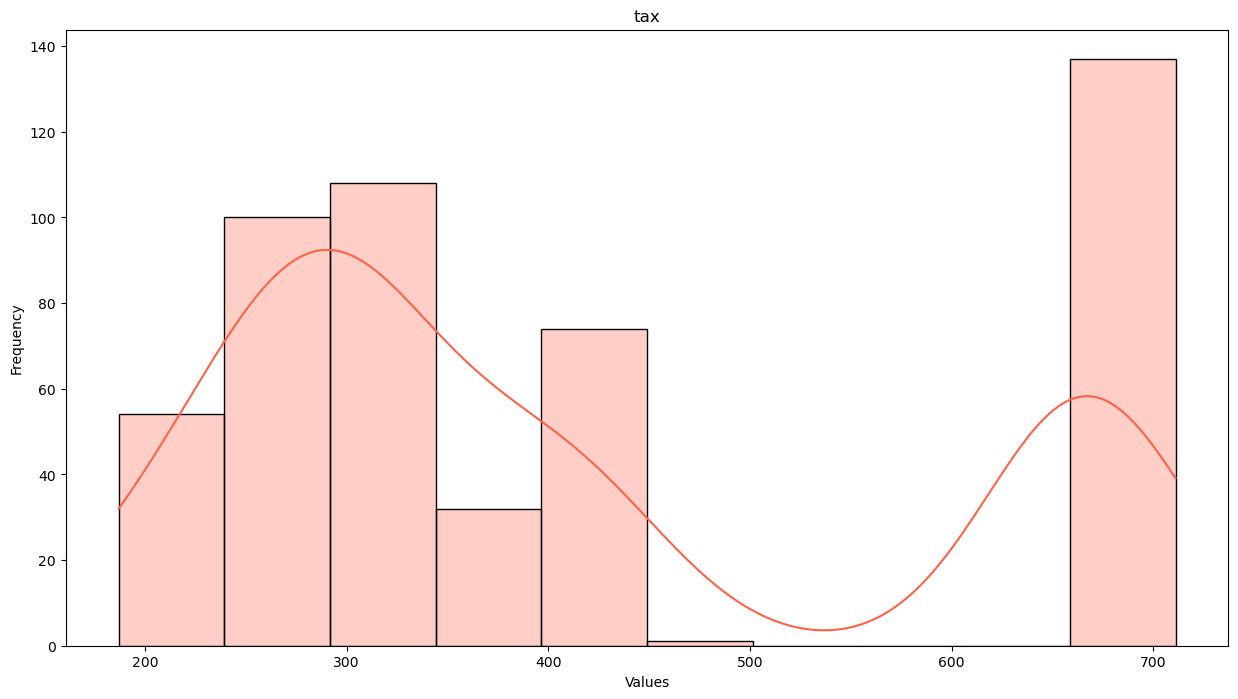

In [8]:
fig, ax = plt.subplots(figsize = (15, 8))
ht = sns.histplot(data=df, x = 'tax',  color='tomato', alpha = 0.3, kde = True)
ax.set_title('tax')
ax.set_xlabel('Values')
ax.set_ylabel('Frequency')

بیشترین مقدار مالیات در بازه 700_600 و کمترین مفدار در بازه 300_200
این توزیع نرمال و یکنواخت نیست چون دو قله داریم

In [9]:
corr_df = df.corr(numeric_only=True)
corr_df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


این دیتافریم به ما رابطه بین هر دو ستون رو در دیتا به ما نشون میده که عدد های بین 1- و 1+ هستند 

Text(0.5, 1.0, 'Corellation Matrix')

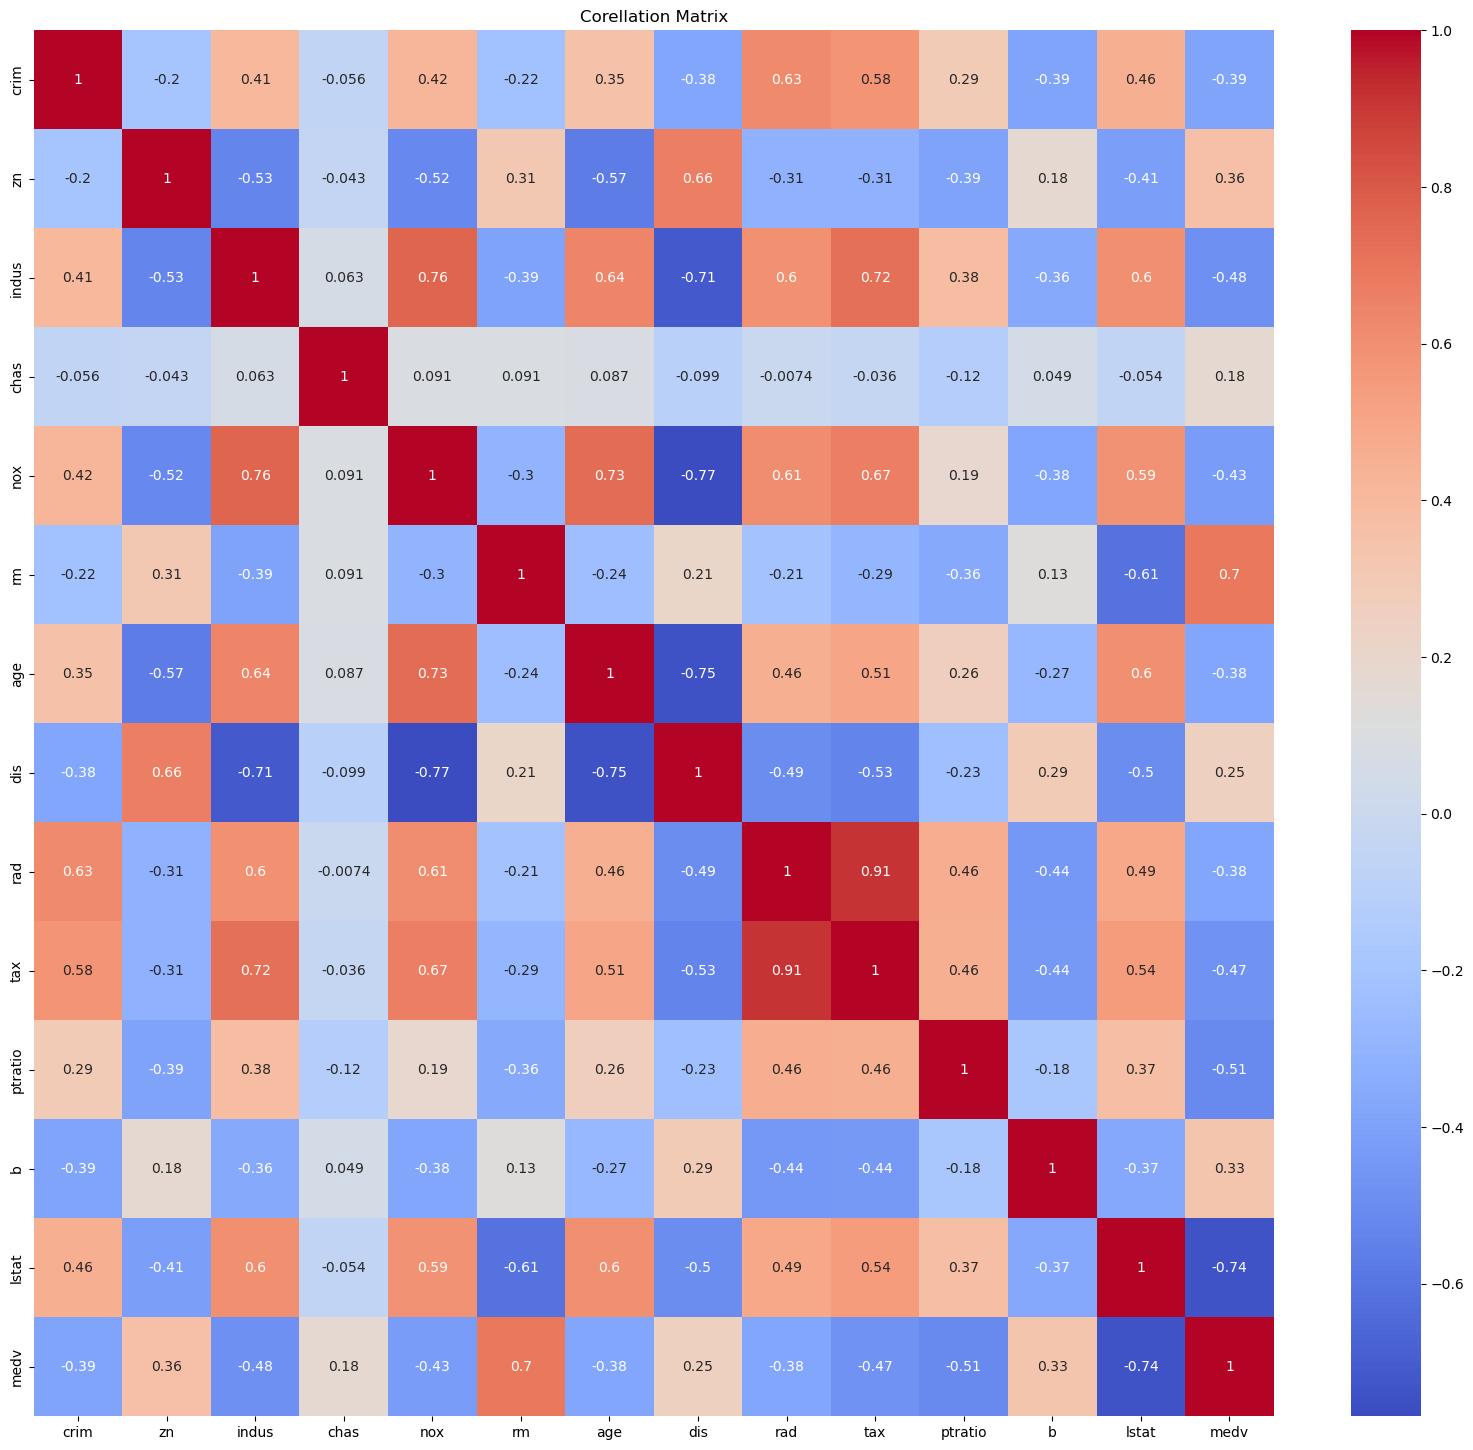

In [10]:
fig, ax = plt.subplots(figsize=(20,18))
sns.heatmap(corr_df,annot=True, cmap = 'coolwarm',xticklabels=True,yticklabels=True)
ax.set_title('Corellation Matrix')


هرچی رنگ خونه ها ابی تر باشه یعنی رابطه منفیه بین ستون ها و با کم شدن یکی اون یکی بیشتره و هرچی رنگ قرمزتر رابطه مثیت.ما بین این دو یعنی رابطه خاصی ندارن یا کمه

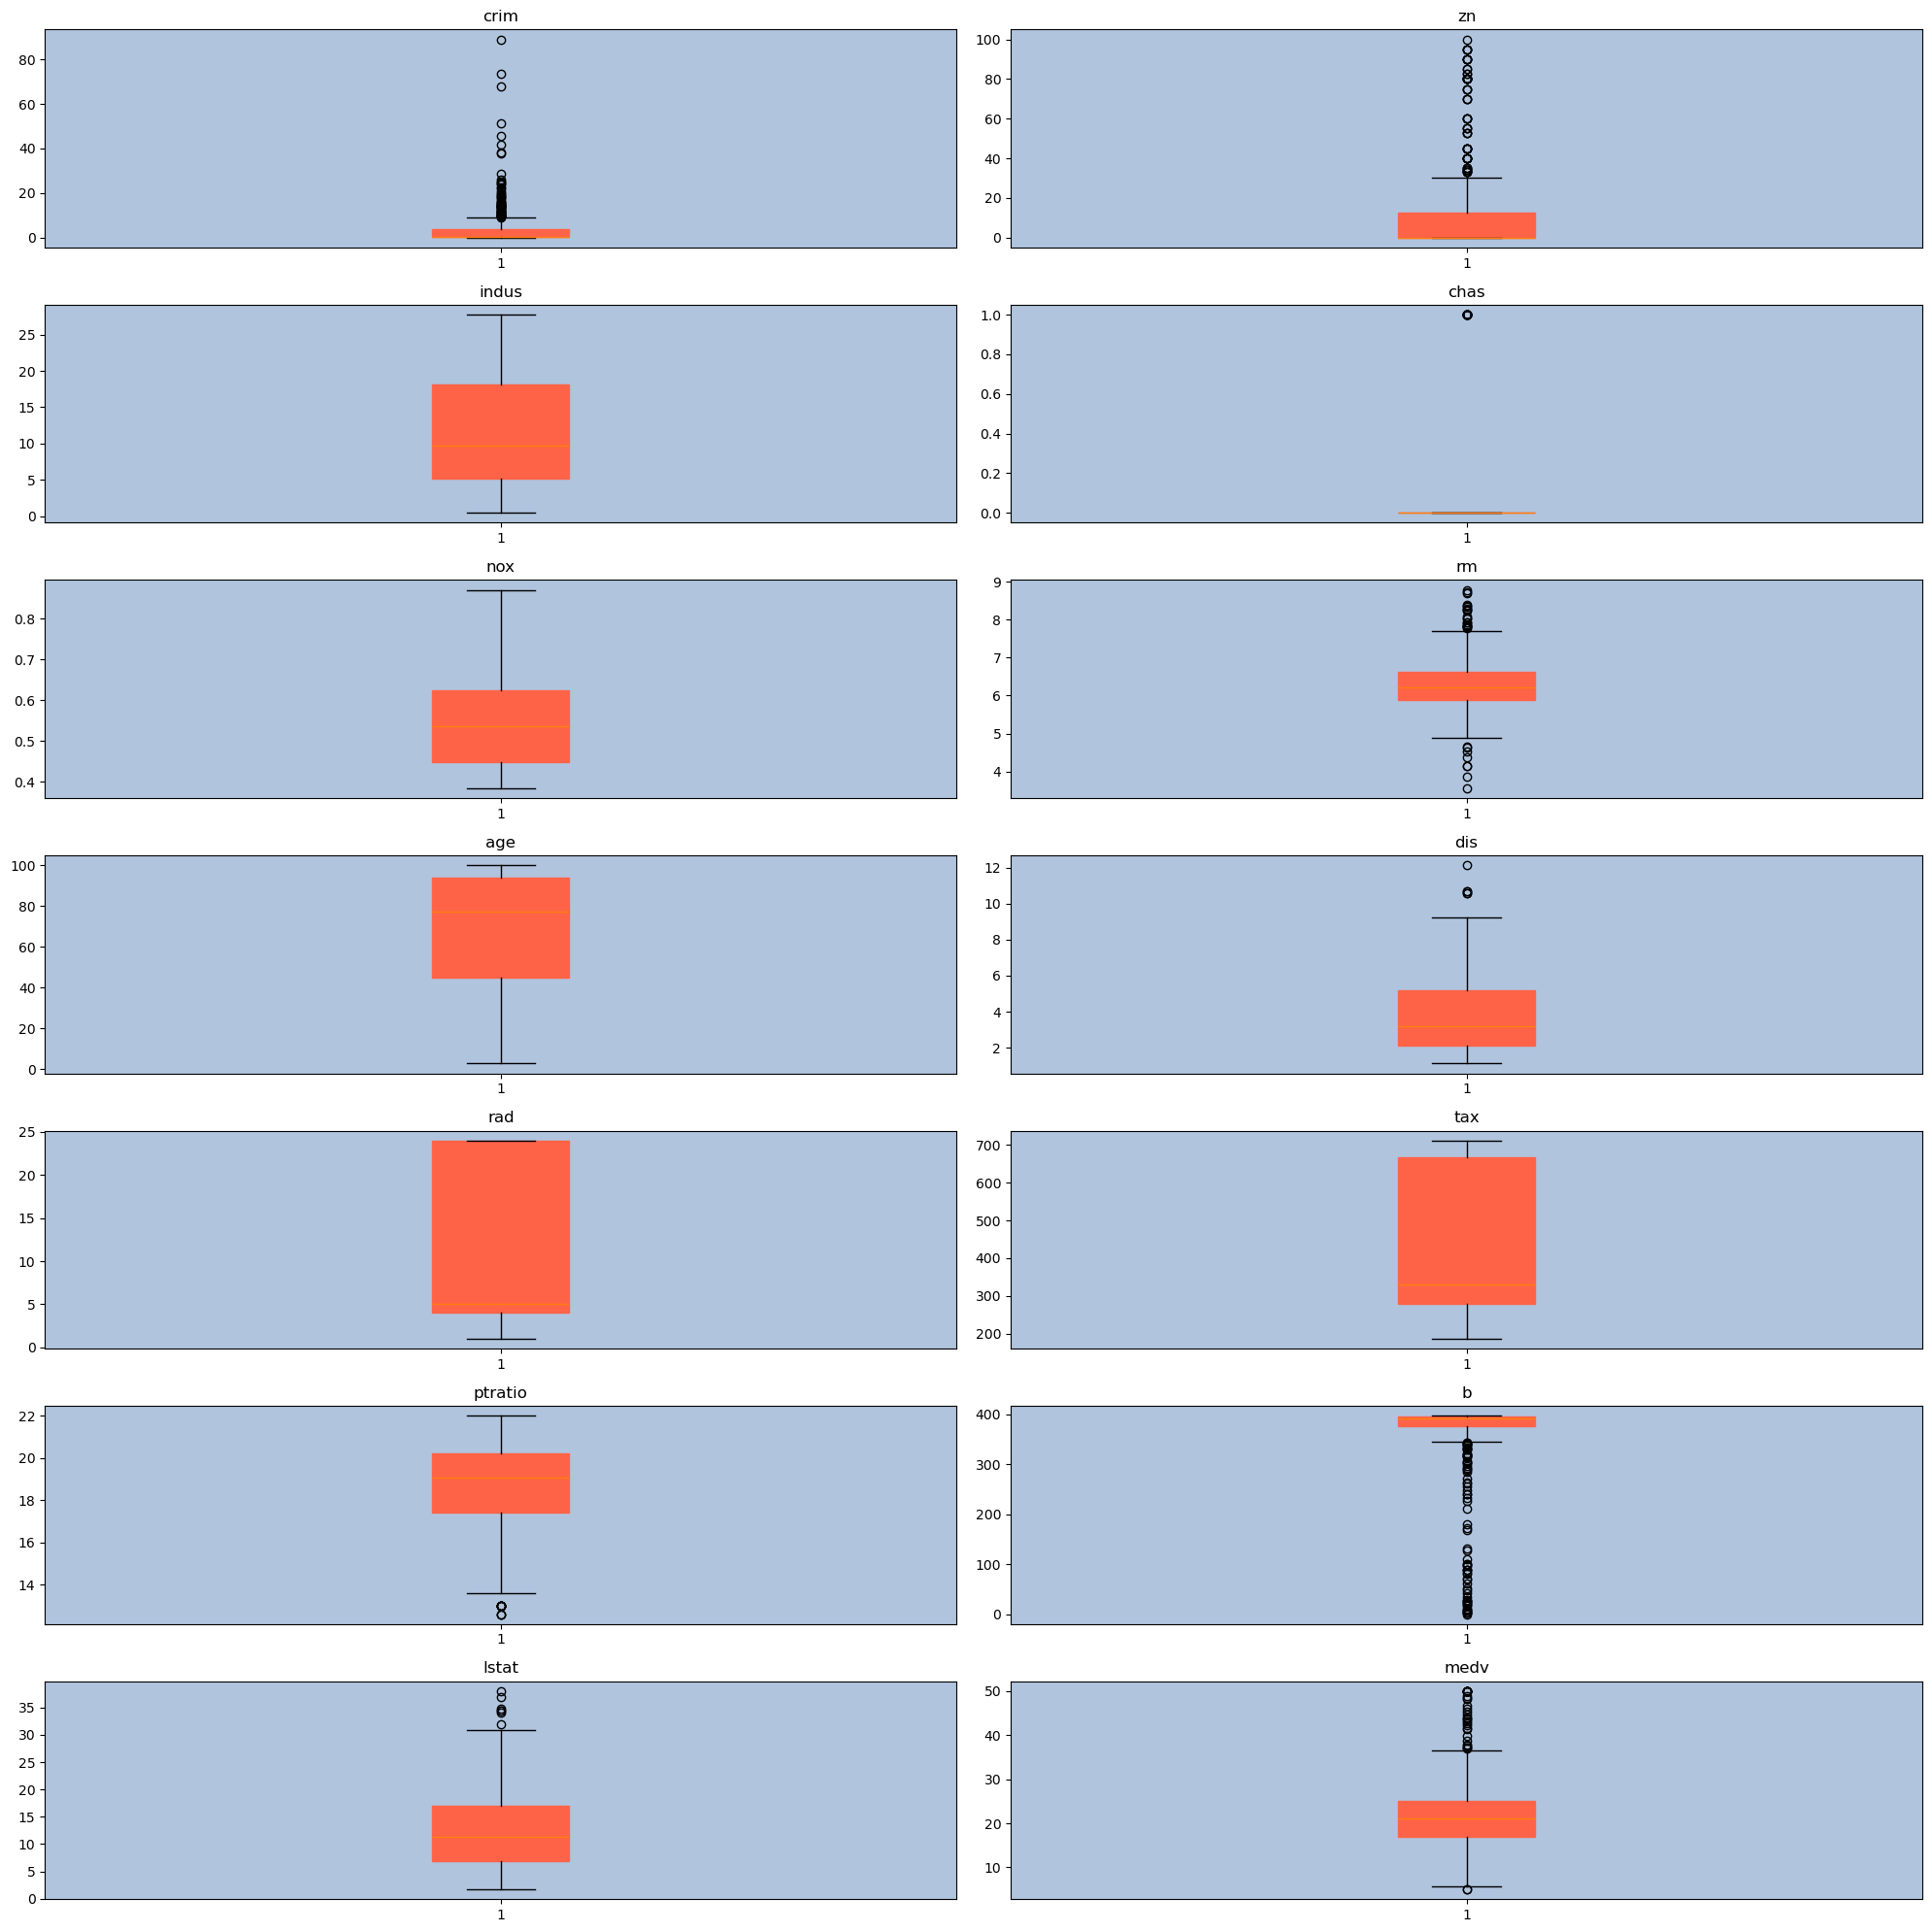

In [11]:
fig, axes = plt.subplots(7,2,figsize=(20,20))
axes = axes.flatten()
for i , col in enumerate(df.columns):
    ax = axes[i]
    ax.set_facecolor('lightsteelblue')
    box = ax.boxplot(df[col],patch_artist=True)

    for b in box['boxes']:
        b.set(color = 'tomato')

    ax.set_title(col)
plt.tight_layout()


In [12]:
df_rep = df.copy()

In [13]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [14]:
df_rep

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [15]:
nonbi = [col for col in df_rep.columns if not set(df_rep[col].unique()).issubset({0,1})]

for col in nonbi:
    q1 ,q3 = np.quantile(df_rep[col],[0.25,0.75])
    iqr = q3-q1

    upper_whisker = q3 + 1.5*iqr
    lower_whisker = q1 - 1.5*iqr

    outlier= df_rep[(df_rep[col] < lower_whisker) | (df_rep[col]> upper_whisker)].index
    print(upper_whisker,lower_whisker)
    df_rep.loc[df_rep[col] < lower_whisker,col]=lower_whisker
    df_rep.loc[df_rep[col] > upper_whisker,col]=upper_whisker




9.06963875 -5.31051125
31.25 -18.75
37.465 -14.175
0.8865 0.18650000000000005
7.730500000000001 4.778499999999999
167.64999999999998 -28.54999999999999
9.820800000000002 -2.5322000000000005
54.0 -26.0
1246.5 -301.5
24.4 13.199999999999998
427.49625000000003 344.10624999999993
31.962500000000006 -8.057500000000005
36.962500000000006 5.0624999999999964


C:\Users\Ghazal\AppData\Local\Temp\ipykernel_10256\2073808091.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-301.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_rep.loc[df_rep[col] < lower_whisker,col]=lower_whisker


In [16]:
df_rep

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [17]:
df_rep.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,2.225032,6.963439,11.136779,0.069170,0.554695,6.275312,68.574901,3.783947,9.549407,408.237154,18.463834,381.918836,12.612011,21.877075
std,3.313353,12.028788,6.860353,0.253994,0.115878,0.630242,28.148861,2.069765,8.707259,168.537116,2.143924,19.054913,7.016829,7.602976
min,0.006320,0.000000,0.460000,0.000000,0.385000,4.778500,2.900000,1.129600,1.000000,187.000000,13.200000,344.106250,1.730000,5.062500
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,9.069639,31.250000,27.740000,1.000000,0.871000,7.730500,100.000000,9.820800,24.000000,711.000000,22.000000,396.900000,31.962500,36.962500


In [18]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


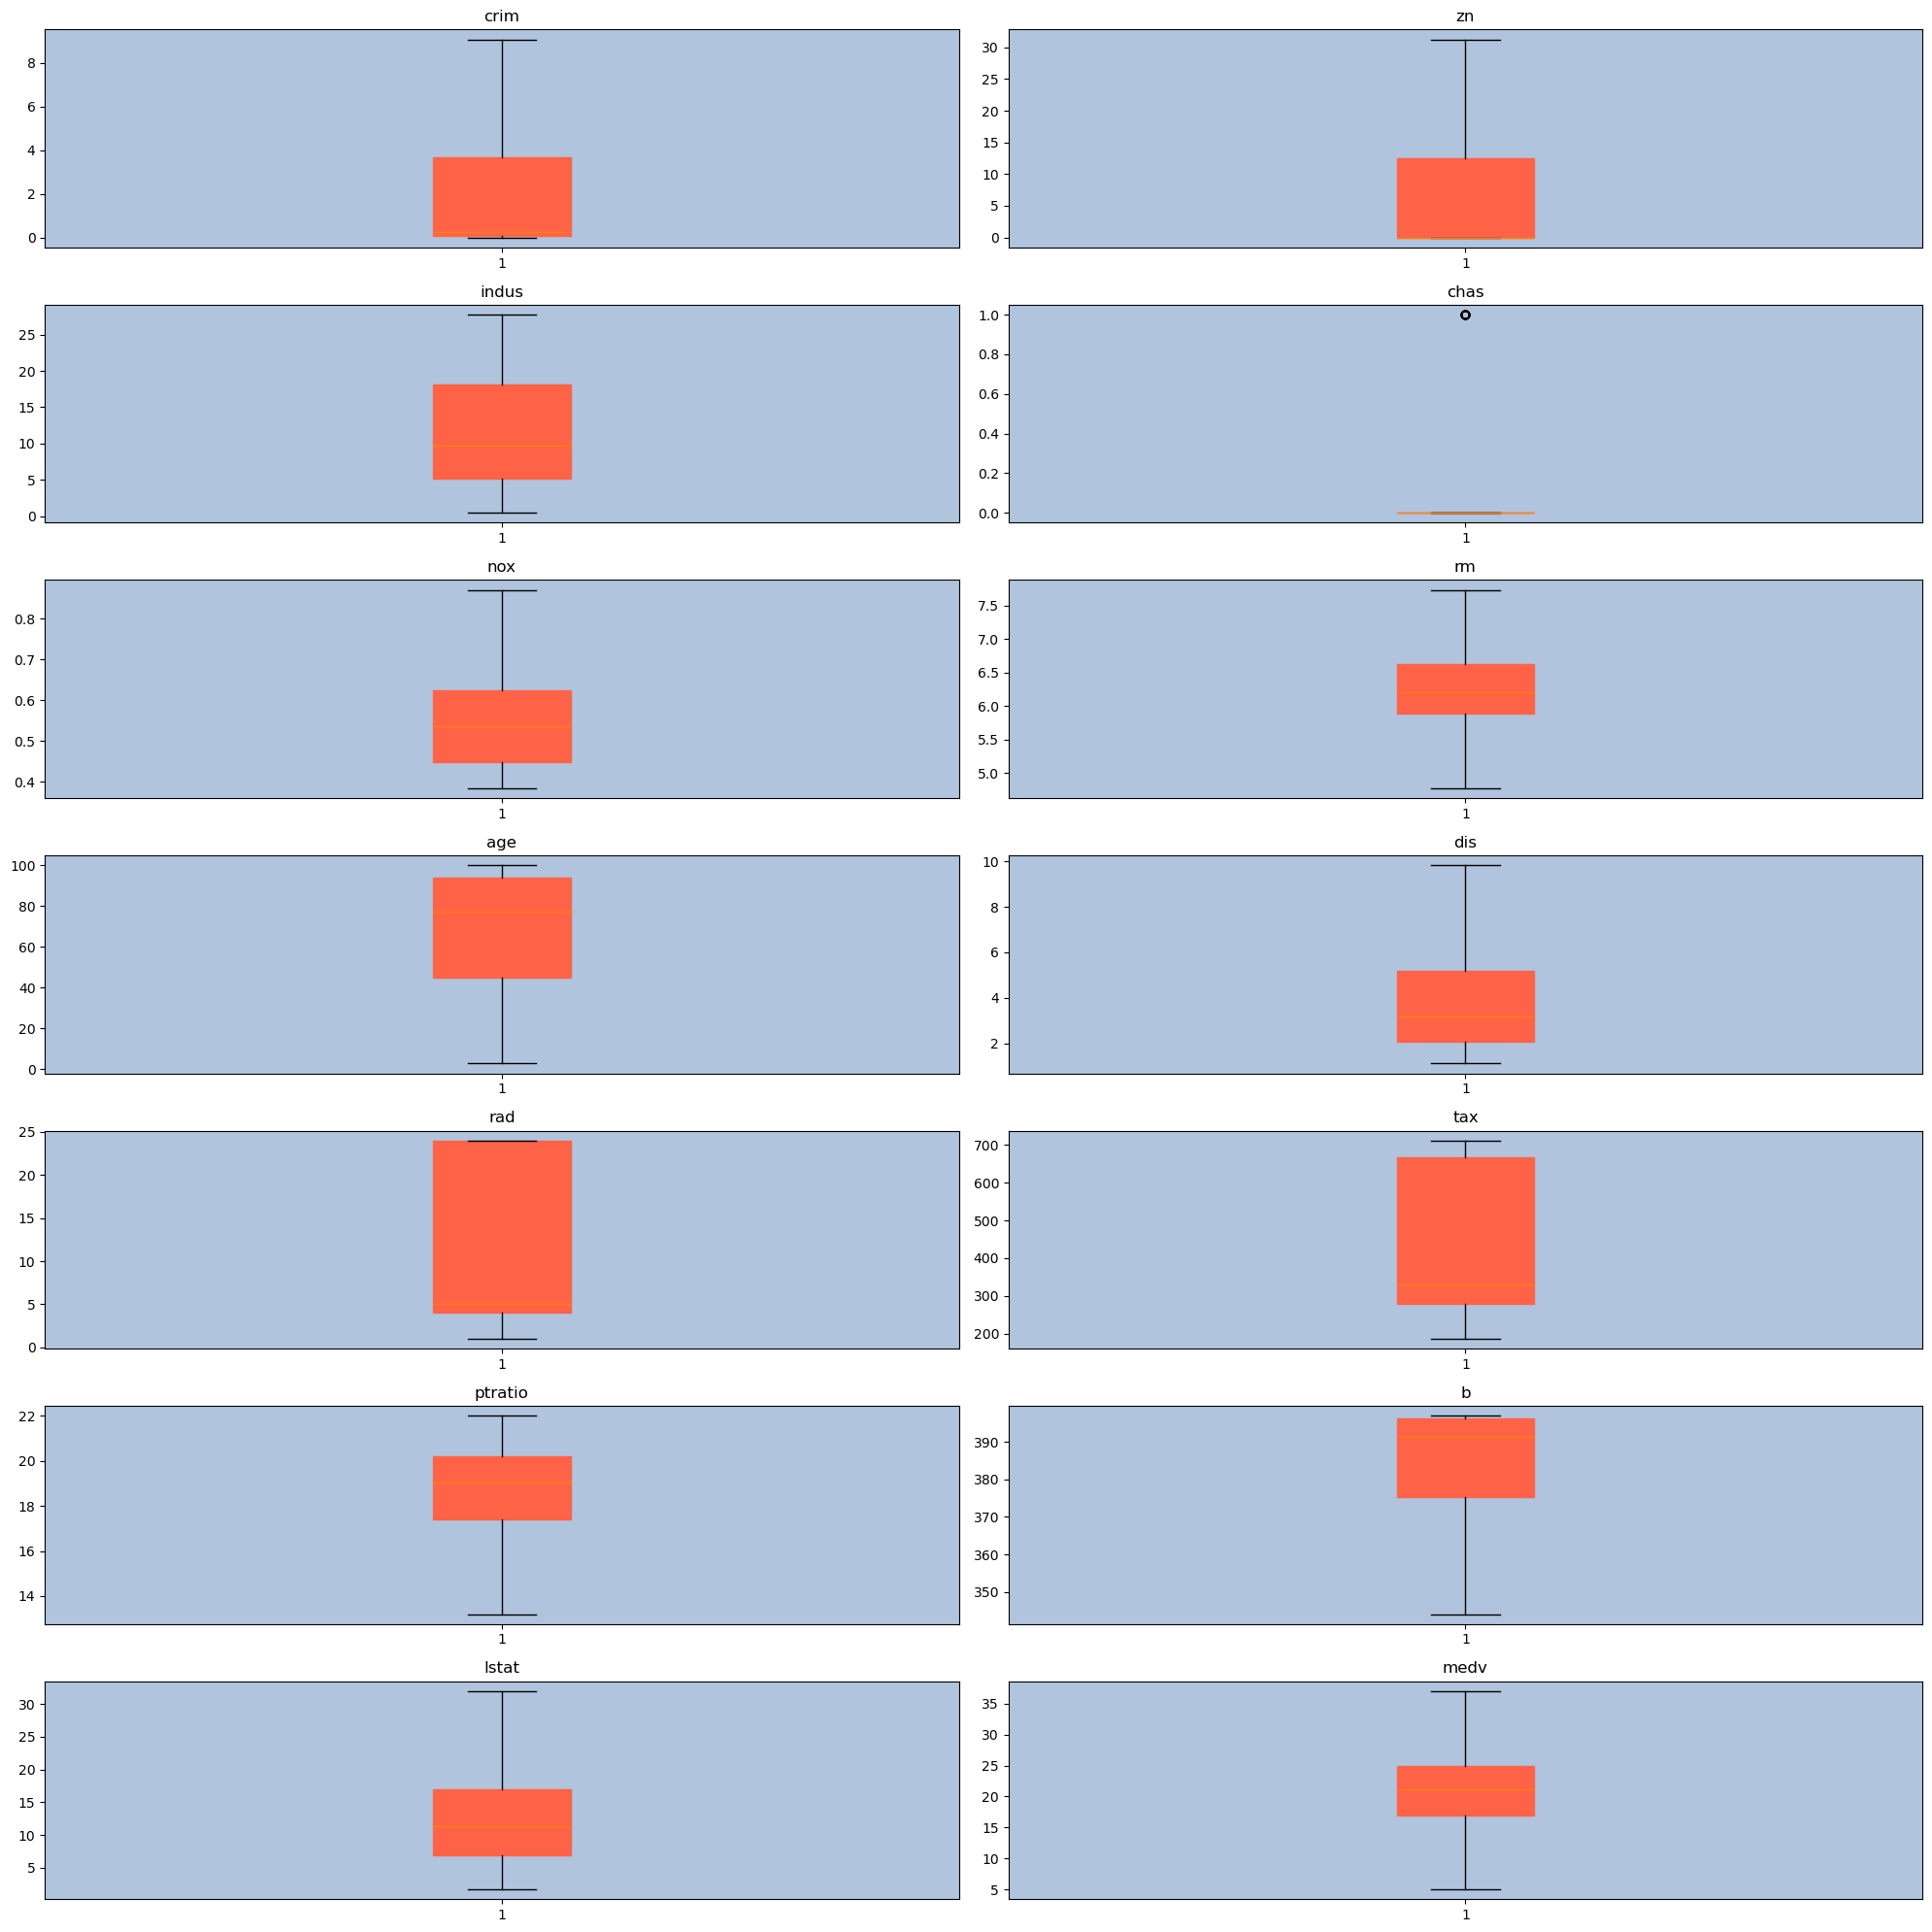

In [19]:
fig, axes = plt.subplots(7,2,figsize=(20,20))
axes = axes.flatten()
for j , col in enumerate(df_rep.columns):
    ax = axes[j]
    ax.set_facecolor('lightsteelblue')
    box = ax.boxplot(df_rep[col],patch_artist=True)

    for o in box['boxes']:
        o.set(color = 'tomato')

    ax.set_title(col)
plt.tight_layout()


In [20]:
df_zscore= df.copy()
df_zscore['z'] = stats.zscore(df_zscore['dis'])
outliersz = df_zscore[df_zscore['z'].abs()>3].index
len(outliersz)


5

In [21]:
df_zscore = df_zscore.drop(index=outliersz)

In [22]:
df_zscore

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,z
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0.140214
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0.557160
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,0.557160
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1.077737
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1.077737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,-0.625796
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,-0.716639
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,-0.773684
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,-0.668437


In [23]:
df_iqr = df.copy()
q1i = df_iqr['dis'].quantile(0.25)
q3i = df_iqr['dis'].quantile(0.75)
iqrd = q3i - q1i
lower = q1i - 1.5*iqrd
upper = q3i + 1.5*iqrd
df_iqr = df_iqr[(df_iqr['dis']>=lower) & (df_iqr['dis']<=upper)]
df_iqr

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [24]:
df_zscorev= df_zscore['dis'].var()
df_iqrv = df_iqr['dis'].var()
var_difference = np.abs(df_zscorev - df_iqrv)
var_difference

0.0

تحلیل رابطه سن بنا و فاصله تا مرکز اشتغال

 Normality Testing (Shapiro–Wilk Test)


- \$ H_0 \$: The data are normally distributed  
- \$ H_1 \$: The data are not normally distributed  

In [25]:
stat, p= stats.shapiro(df_zscore['dis'])
print(f'shipro wilk test\nstatics = {stat : .4f},p_value = {p : .4f}')

shipro wilk test
statics =  0.9093,p_value =  0.0000


با توجه به اینکه p-value کمتر از سطح معنی‌داری 0.05 است،
 فرض نرمال بودن داده‌ها رد می‌شود.
بنابراین ستون dis نا‌نرمال است

In [26]:
x = df_zscore['dis']
x_log = np.log1p(x)

original skew: 0.841223595417712
log_transformed skew 0.28081038989122736


(array([ 6.,  8., 15., 22., 18., 28., 25., 28., 23., 26., 21., 20., 13.,
        20., 18., 14., 26., 17., 15.,  9., 16., 23., 13., 16., 16.,  6.,
        13., 13.,  4.,  9.]),
 array([0.75593417, 0.80822404, 0.86051391, 0.91280378, 0.96509365,
        1.01738352, 1.0696734 , 1.12196327, 1.17425314, 1.22654301,
        1.27883288, 1.33112275, 1.38341262, 1.43570249, 1.48799236,
        1.54028224, 1.59257211, 1.64486198, 1.69715185, 1.74944172,
        1.80173159, 1.85402146, 1.90631133, 1.9586012 , 2.01089108,
        2.06318095, 2.11547082, 2.16776069, 2.22005056, 2.27234043,
        2.3246303 ]),
 <BarContainer object of 30 artists>)

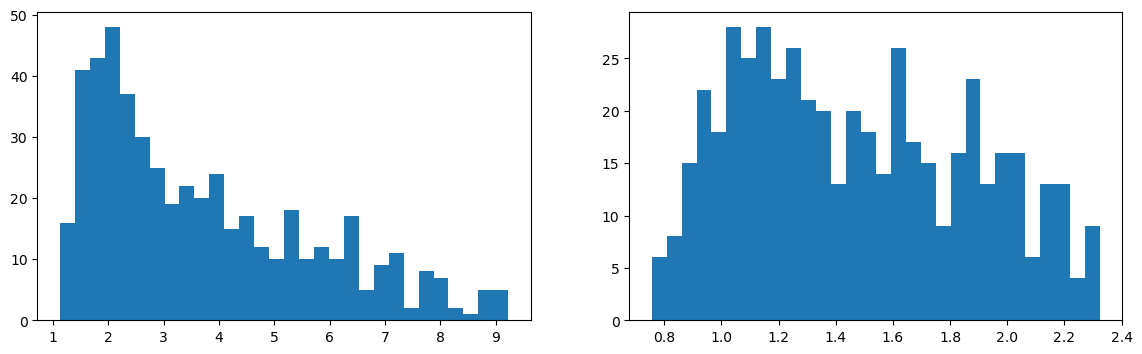

In [27]:
print('original skew:',stats.skew(x))
print('log_transformed skew',stats.skew(x_log))
fig, axs = plt.subplots(1,2,figsize = (14,4))
axs[0].hist(x,bins= 30)
axs[1].hist(x_log,bins=30)


نمودار اول قبل از نرمال سازی با روش لگاریتم که به سمت راست چوله و تمرکز دیتا و قله اصلی سمت چپ و از میانگین کمتر است  و مقدارش زیاده 
بعد از سعی بر نرمال سازی مقار چولگی کم شده ولی نرمال نشده هنوز و چند قله ایه و داده ها از تمرکزشون تو سمت چپ کمتر شده و حوالی میانگین پخش شدن و چولگی به 0.28 از 0.84 کمتر شده

In [28]:
stat, p= stats.shapiro(x_log)
print(f'shipro wilk test\nstatics = {stat : .4f},p_value = {p : .4f}')

shipro wilk test
statics =  0.9599,p_value =  0.0000


سعی کردم با روش لگاریتم نرمالش کنم ولی همچنان نرمال نیست . p از 0.05 کمتره 

In [29]:
transformed_data, best_lambda = boxcox(df_zscore['dis'])
print(f'optimal lambda : {best_lambda}')

optimal lambda : -0.12221546241863313


In [30]:
stat, p= stats.shapiro(transformed_data)
print(f'shipro wilk test\nstatics = {stat : .4f},p_value = {p : .4f}')

shipro wilk test
statics =  0.9703,p_value =  0.0000


از روش boxox سعی کردم نرمالش کنم که باز هم نشد پس از زوش نانپارامتریک استفاده میکنیم
لاندا هم -0.12 به دست اومد و این نشون میده که تبدیل سبک معکوسه و داده اصلی که به راست چوله بود رو به شکل تقزیبی متقارن تر کرد ولی همچنان نرمال نیست 

حالا که توزیع نرمال  نیست و از زوش نان پارامتریک mann-whitney استفاده میکنیم برای اینکه بدونبم فاصله خانه ها از مراکز شغلی بین دو گروه سنی فرق داره یا نه از این ازمون استفاده میکنیم مه برای مقایسه دو گروه مستقل اند 
گروه اول خانه های با سن کمتر از میانه یا مساوی و گروه دوم با سن بیشتر از میانه 
و ستون age_bianary که یک ستون کمکی برای تغیین گروه هاست با مقدار صفر و یک برای فیلتر کردن داده ها و دسته بندی


In [31]:
med = df_zscore['age'].median()
df_zscore['age_binary']=np.where(df_zscore['age']<= med, 0 , 1)
old = df_zscore[df_zscore['age']>med]
new = df_zscore[df_zscore['age']<=med]
print(len(new),len(old))

251 250


In [32]:
df_zscore

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,z,age_binary
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0.140214,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0.557160,1
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,0.557160,0
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1.077737,0
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1.077737,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,-0.625796,0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,-0.716639,0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,-0.773684,1
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,-0.668437,1


تعریف تابع تحلیل

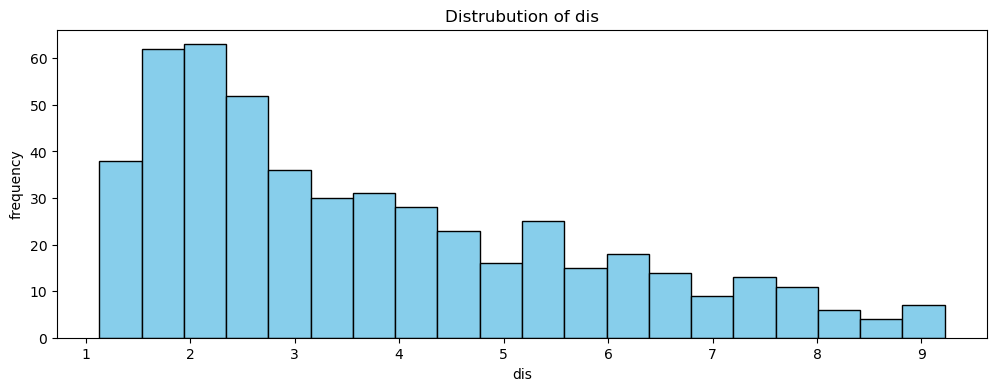

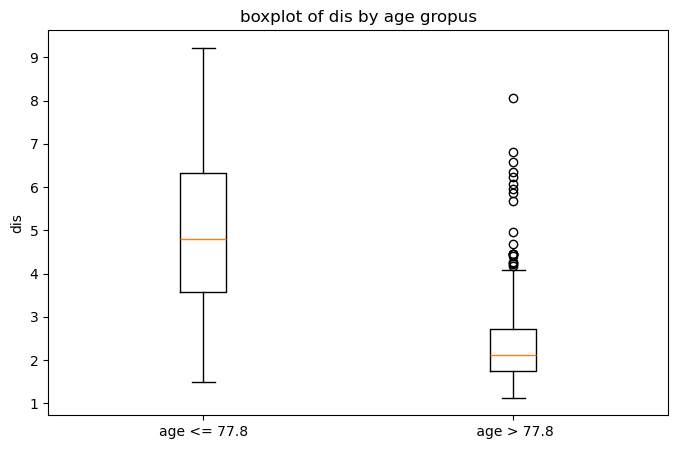

mann_whitney u test :
 u_statics : 57045.5000, p_value: 0.0000


In [33]:
def analyze_dis_vs_age_binary(df_zscore,feature = 'dis', target = 'age_binary',bins = 20, n_perm = 1000, alpha= 0.05):
    #hist
    plt.figure(figsize=(12,4))
    plt.hist(df_zscore[feature],bins=bins,color = 'skyblue',edgecolor = 'black')
    plt.title(f'Distrubution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('frequency')
    plt.show()

    #boxplot
    categories = df_zscore[target].unique()
    group0 = df_zscore.loc[df_zscore[target]==categories[0],feature]
    group1 = df_zscore.loc[df_zscore[target]==categories[1],feature]
    plt.figure(figsize=(8,5))
    plt.boxplot([group0,group1],labels=[f'age <= {med}',f' age > {med}'])
    plt.title(f'boxplot of {feature} by age gropus')
    plt.ylabel(feature)
    plt.show()
    #mann_whitey u test
    u_stat , p_mwu= stats.mannwhitneyu(group0,group1,alternative='two-sided')
    print(f'mann_whitney u test :\n u_statics : {u_stat:.4f}, p_value: {p_mwu:.4f}')

analyze_dis_vs_age_binary(df_zscore)

باکس پلات نشون میدهد که میانه فاصبه خانه های قدیمی تر تقریبا 2 و خانه های جدیدتر 5 و پراکندگی خانه های قدیمی کمتر است هر.ند داده های پرت هم دیده میشه و ازمون ما و پی ولیو که کمتر از مقدار معنا داری شده نشون میدهد که شواهد کافی برای اثبات فرض صفر ما که وجود نداشتن تفاوت بین فاصله خانه های جدید با قدیمی بود را نداریم و نتیجه گرفتیم که خانه های قدیمی به طور معنی داری به مراکز شغلی نردیکترن

تحلیل تفاوت غلظت NOX بین دو گروه PTRATIO (کمتر/بیشتر از میانه)

In [34]:
med_ptratio = df_zscore['ptratio'].median()
df_zscore['ptratio_binary']=np.where(df_zscore['ptratio']>med_ptratio,1,0)
df_zscore

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,z,age_binary,ptratio_binary
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0.140214,0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0.557160,1,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,0.557160,0,0
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1.077737,0,0
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1.077737,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,-0.625796,0,1
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,-0.716639,0,1
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,-0.773684,1,1
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,-0.668437,1,1


In [35]:
g0 = df_zscore[df_zscore['ptratio_binary']==0]['nox']
g1 = df_zscore[df_zscore['ptratio_binary']==0]['nox']

تست نرمال بودن هر گروه


In [36]:
stat0, p0 = stats.shapiro(g0)
print(f'statics = {stat0:.4f}, pvalue = {p0:.4f}')
stat1, p1 = stats.shapiro(g1)
print(f'statics = {stat1:.4f}, pvalue = {p1:.4f}')

statics = 0.7598, pvalue = 0.0000
statics = 0.7598, pvalue = 0.0000


دیدیم که با توجه به پی ولیو که کمتر از مقدار معنا داریه نرمال نیست توزیع ما پس سعی میکنیم نرمالش کنیم با روش boxcox
 چون این روش برای مقادیر مثبته پس مینش رو چک میکنیم

In [37]:
df_zscore['nox'].min()

0.385

In [38]:
boxcoxz, lambdaz = boxcox(df_zscore['nox'])
print(f'lambda : {lambdaz}')
s , p = stats.shapiro(df_zscore['nox'])
print(f'statics after normalizing : {s:.4f}, pvalue :{p:.4f}')

lambda : -0.8955337860547852
statics after normalizing : 0.9370, pvalue :0.0000


لاندا تقریبا منفی یک شده که نشون میده این توزیع به شدت چوله راست بوده


بعد از نرمال سازی همچنان نرمال نشده چون pvalue از 0.05 کمتر شده



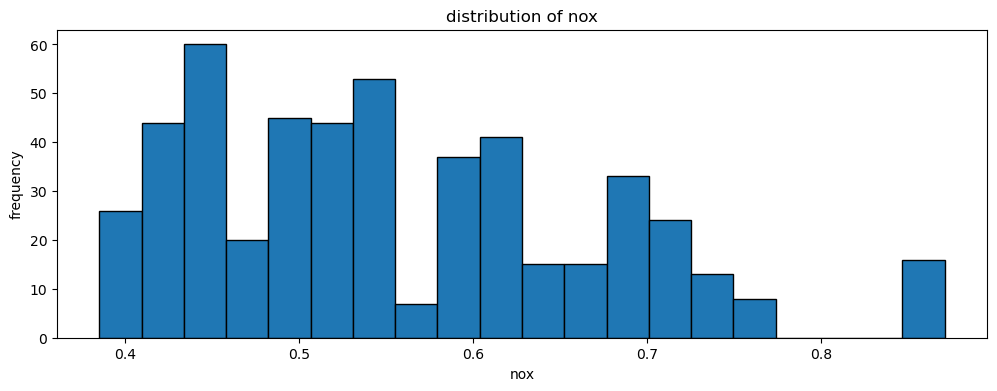

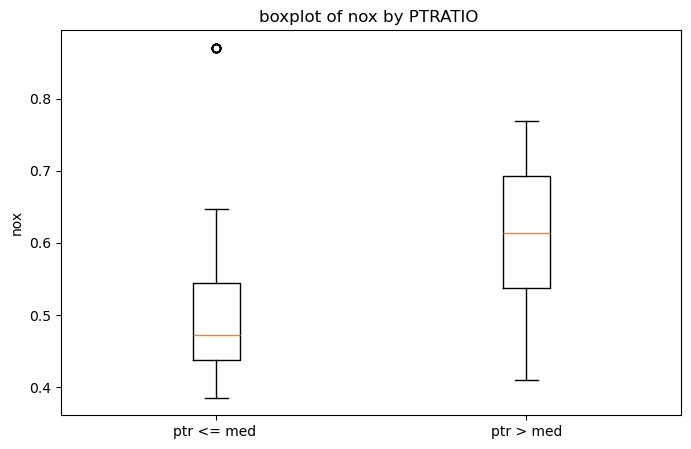

mann_whitnry u test :
 ustatics : 11943.0000,p_value : 0.0000


In [39]:
def analyze_nox_vs_ptratio(df_zscore,feature = 'nox',target='ptratio_binary',bins=20,alpha=0.05):
    plt.figure(figsize=(12,4))
    plt.hist(df_zscore[feature],bins=bins,edgecolor = 'black')
    plt.title(f'distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('frequency')
    plt.show()


    categories = df_zscore[target].unique()
    g0 = df_zscore.loc[df_zscore[target]==categories[0],feature]
    g1 = df_zscore.loc[df_zscore[target]==categories[1],feature]

    plt.figure(figsize=(8,5))
    plt.boxplot([g0,g1],labels = ['ptr <= med ','ptr > med'])
    plt.title(f'boxplot of {feature} by PTRATIO ')
    plt.ylabel(feature)
    plt.show()



    ustat , p_value = stats.mannwhitneyu(g0,g1,alternative='two-sided')
    print(f'mann_whitnry u test :\n ustatics : {ustat:.4f},p_value : {p_value:.4f}')


analyze_nox_vs_ptratio(df_zscore)

گروه صفر مناطق با نسبت کمتر دانش اموز به معلم بودن و مدارس خلوت تر 
گروه یک مناطق با نسبت بیشر از میانه و دانش اموز به معلم با مدارس شلوغ تر
و هیستوگرام نشون داد که غیرنرماله و از ازمون نانپارامتریک استفاده کردیم 
باکس پلات در دوگروه نشون داد که گروه یک که مدارس شلوغ تری داره الودگیش بیشتره و گروه مدارس خلوت تر با میانه پایین تر نشان داد هواش پاکتره

و با به دست اوردن pvalue با ازمون نتیجه گرفتیم که شواهد کاغی برای اثبات فرض صفر ما که یکسان بودن توزیع الودگی در دو گروه بود نداشتیم و  با صفر شدن پی ولیو
و فرض متقابل که تفاوت nox در دو گروه بود تایید شد چون میزان نیتریک اسید در مناطقی که تعداد دانش اموزان به معلم بیشتر است به طور معناداری بالاتر است

تحلیل تاثیز تراکم حمعیت بر تعداد اتاق هاای واحد مسکونی

In [40]:
meanistat = df_zscore['lstat'].mean()
df_zscore['dense_group']=np.where(df_zscore['lstat']< meanistat,0,1)
gl = df_zscore[df_zscore['dense_group']==0]['rm']
gh = df_zscore[df_zscore['dense_group']==1]['rm']


In [41]:
df_zscore

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,z,age_binary,ptratio_binary,dense_group
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0.140214,0,0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0.557160,1,0,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,0.557160,0,0,0
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1.077737,0,0,0
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1.077737,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,-0.625796,0,1,0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,-0.716639,0,1,0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,-0.773684,1,1,0
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,-0.668437,1,1,0


In [42]:
staticl, pl = stats.shapiro(gl)
print(f'statics : {staticl:.4f},pvalue : {pl:.4f}')
statich, ph = stats.shapiro(gh)
print(f'statics:{statich:.4f}, pvalue: {ph:.4f}')


statics : 0.9496,pvalue : 0.0000
statics:0.9590, pvalue: 0.0000


پی ولیو برای هر دو گروه صفر شد و نشان میدهد که داده ها نرمال نیستن و فرض نرمال بودن برقرار نیست 

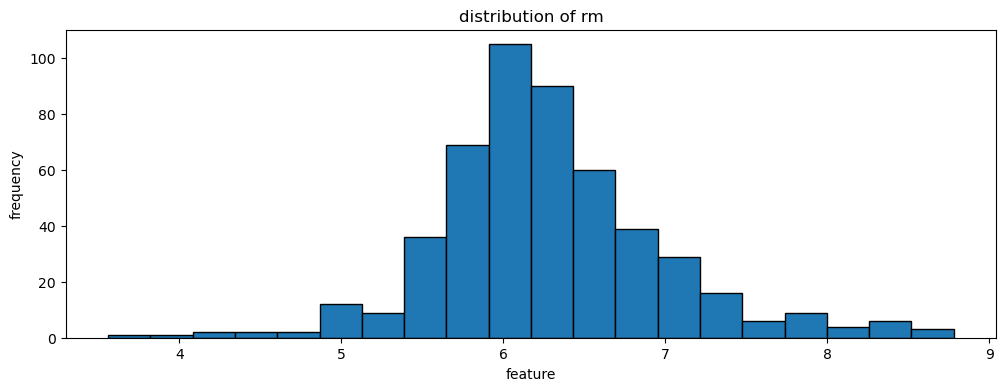

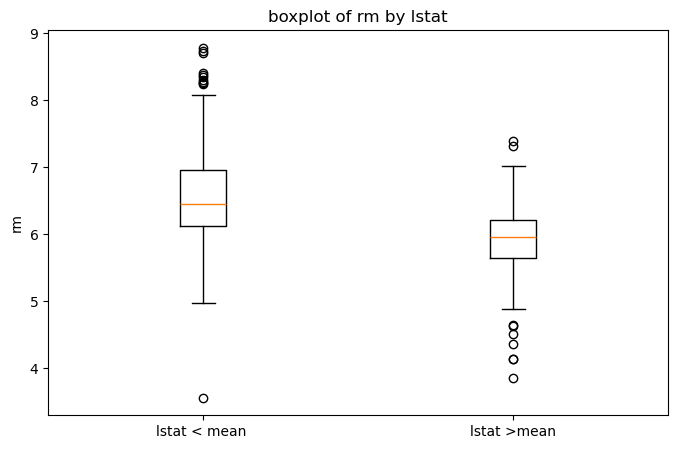

statics : 48973.0000,pvalue :0.0000


In [43]:
def analyze_rm_vs_lstat(df_zscore,feature='rm',target='dense_group',bins=20,alpha=0.05):
    plt.figure(figsize=(12,4))
    plt.hist(df_zscore[feature],bins=bins,edgecolor = 'black')
    plt.title(f'distribution of {feature}')
    plt.xlabel('feature')
    plt.ylabel('frequency')
    plt.show()


    categories = df_zscore[target].unique()
    gl= df_zscore.loc[df_zscore[target]==categories[0],feature]
    gh= df_zscore.loc[df_zscore[target]==categories[1],feature]

    plt.figure(figsize=(8,5))
    plt.boxplot([gl,gh],labels = ['lstat < mean ','lstat >mean'])
    plt.title(f'boxplot of {feature} by lstat')
    plt.ylabel(feature)
    plt.show()


    staticss, ppv= stats.mannwhitneyu(gl,gh,alternative='greater')
    print(f'statics : {staticss:.4f},pvalue :{ppv:.4f}')


analyze_rm_vs_lstat(df_zscore)

تعداد اتاق ها در دو گروه با نمودار ها نشان  داد که میانه تعداد اتاق ها در مناطق کم تراکم تر بالاتر است
مناطق پر تراکم تر خانه هایی با تعداد اتاق کمتر و پراکندگی محدود تری دارن
و از ازمون اسفاده شده فهمیدیم که شواهد کاغی برای تایید فرض صفر که برابری توزیع دو گروه بود نداشتیم 